In [1]:
import numpy as np
from mes_packages import *


=== Vérification de l'orientation des triangles ===
Nombre total de triangles: 1425

Nombre de triangles corrigés: 0/1425
Tous les triangles étaient déjà correctement orientés True
Nombre d'éléments : 1425
Nombre de sommets : 805


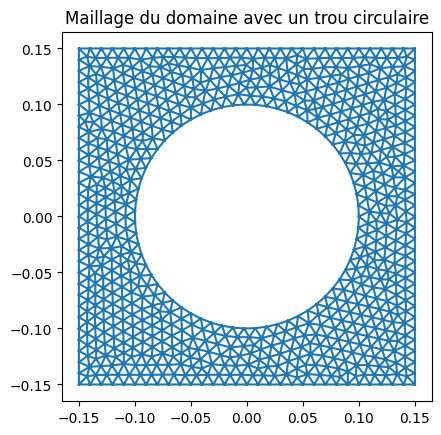

In [ ]:
# Domaine test : un carré contenant un disque.
# Cela permet de vérifier que la localisation fonctionne aussi
# près de frontières non alignées avec la grille cartésienne.
#
# Paramètres :
# 0.3  -> taille caractéristique du maillage extérieur
# 0.1  -> rayon du disque 
# 0.01 -> pas du maillage  

mesh = create_mesh_circle_in_square(0.1, 0.3, 0.01)
plot_mesh(mesh)

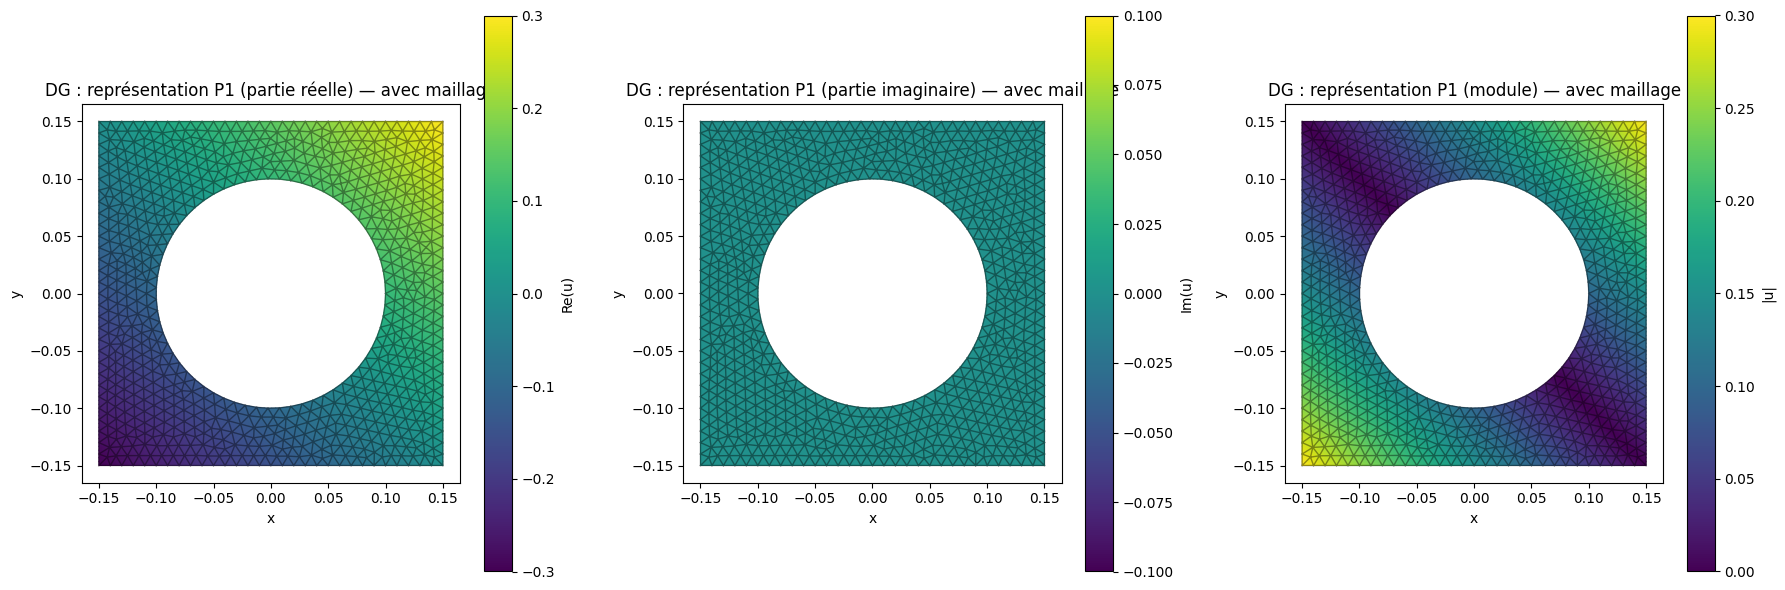

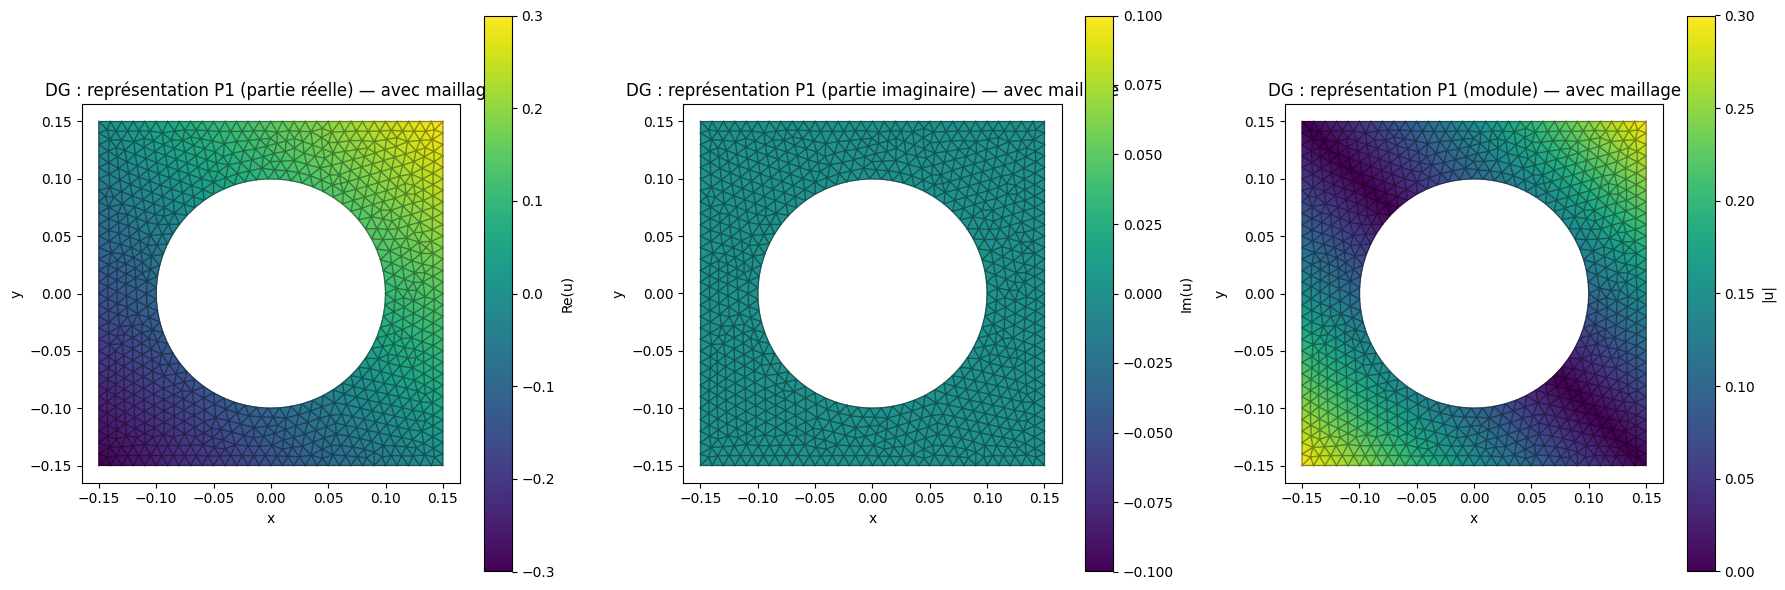

In [ ]:
ordre = 3

# Construction de la grille spatiale (prétraitement fait une seule fois)
spgrid = build_spatial_grid(mesh)

# ------------------------------------------------------------------
# 1) Construction d'une fonction EF de référence
# ------------------------------------------------------------------
# Ici on prend une fonction simple pour validation :
# u(x,y) = x + y
Uh = build_nodal_vector_CG(lambda x, y: x + y, mesh, ordre)

# ------------------------------------------------------------------
# 2) Construction d'une fonction "boîte noire" qui évalue u_h(x,y)
#    via la localisation géométrique
# ------------------------------------------------------------------
func = lambda X, Y: eval_CG_point(Uh, mesh, ordre, X, Y, spgrid)

# ------------------------------------------------------------------
# 3) Ré-interpolation dans l'espace EF
# ------------------------------------------------------------------
# On reconstruit un vecteur nodal en échantillonnant u_h
Uh2 = build_nodal_vector_CG(func, mesh, ordre)